# IGN (InteractionGraphNet) 虚拟筛选教程

对应书稿章节：3.3.2.1 构建蛋白-小分子复合 GNN。
教学数据：使用 `demo_data/CoreSet.dat` 中的 20 个代表性复合物子集，不等同于完整 CASF-2016 core set。

本 notebook 只保留 **交互边聚合回归亲和力** 这条技术路线。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `Pearson R` 和 `RMSE`

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.spatial import distance_matrix
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from rdkit import RDLogger
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

# 定位项目根目录并设置 import 路径
_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, atom_features, build_mlp, describe_model_parameters,
    history_frame, load_complex, metric_frame, parse_coreset, plot_loss_curves,
)

## 1. 超参数设置

| 参数 | 含义 | 说明 |
|------|------|------|
| `DISTANCE_CUTOFF` | 交互图边的距离阈值 | 蛋白-配体原子对距离 < 该值时建立边，原始论文常用 5.0 Å |
| `ATOM_FEAT_DIM` | 原子特征维度 | 10 维：8 种常见元素 one-hot + other + 芳香性 |
| `HIDDEN_DIM` | 隐层维度 | 节点嵌入和边 MLP 的隐藏层维度 |
| `N_EPOCHS` | 训练轮数 | 在 20 个代表性复合物的教学子集上训练 |
| `BATCH_SIZE` | 批大小 | 变长图，设为 1 逐样本处理 |

In [2]:
DISTANCE_CUTOFF = 5.0
HIDDEN_DIM = 128
N_EPOCHS = 200
LR = 1e-3
BATCH_SIZE = 1
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"设备: {DEVICE}")
print(f"距离阈值: {DISTANCE_CUTOFF} Å")
print(f"原子特征维度: {ATOM_FEAT_DIM}")
print(f"隐层维度: {HIDDEN_DIM}")
print(f"训练轮数: {N_EPOCHS}")

设备: cuda
距离阈值: 5.0 Å
原子特征维度: 10
隐层维度: 128
训练轮数: 200


## 2. 数据加载与特征提取

本教学 notebook 使用 **PDBbind CASF-2016 core set 的 20 个代表性复合物子集**，对应 `demo_data/CoreSet.dat` 中的样本，而非完整的 285 个复合物。

**原子特征** (10 维)：元素 one-hot (C, N, O, S, F, P, Cl, Br, other) + 芳香性。

**交互图**：配体-蛋白原子对距离 < 5 Å 的形成边，边特征为欧氏距离。

In [3]:
def build_interaction_data(pdbid):
    """构建单个蛋白-配体复合物的交互图数据。"""
    cplx = load_complex(pdbid, COMPLEX_DIR)
    prot_mol, lig_mol = cplx["prot_mol"], cplx["lig_mol"]
    prot_coords, lig_coords = cplx["prot_coords"], cplx["lig_coords"]

    prot_feats = np.array([atom_features(a) for a in prot_mol.GetAtoms()], dtype=np.float32)
    lig_feats = np.array([atom_features(a) for a in lig_mol.GetAtoms()], dtype=np.float32)

    dist_mat = distance_matrix(lig_coords, prot_coords)
    lig_idx, prot_idx = np.where(dist_mat < DISTANCE_CUTOFF)
    edge_index = np.stack([lig_idx, prot_idx], axis=0)
    edge_dist = dist_mat[lig_idx, prot_idx].reshape(-1, 1)
    return lig_feats, prot_feats, edge_index, edge_dist


labels = parse_coreset(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(labels)} 个复合物标签")

all_data = []
for pdbid, logKa in sorted(labels.items()):
    lig_f, prot_f, ei, ed = build_interaction_data(pdbid)
    all_data.append((lig_f, prot_f, ei, ed, logKa))

print(f"成功加载 {len(all_data)} 个复合物")

从 CoreSet.dat 读取到 20 个复合物标签
成功加载 20 个复合物


In [4]:
sample = all_data[0]
display(pd.DataFrame({
    '数据项': ['配体原子特征', '蛋白原子特征', '交互边索引', '边距离', '标签 (logKa)'],
    '形状': [str(sample[0].shape), str(sample[1].shape), str(sample[2].shape),
            str(sample[3].shape), str(sample[4])],
    '说明': [
        f'{sample[0].shape[0]} 个配体原子, 每个 {sample[0].shape[1]} 维特征',
        f'{sample[1].shape[0]} 个蛋白原子, 每个 {sample[1].shape[1]} 维特征',
        f'{sample[2].shape[1]} 条交互边',
        f'{sample[3].shape[0]} 条边的欧氏距离',
        '实验测量的结合亲和力'
    ]
}))

,数据项,形状,说明
0,配体原子特征,"(36, 10)","36 个配体原子, 每个 10 维特征"
1,蛋白原子特征,"(614, 10)","614 个蛋白原子, 每个 10 维特征"
2,交互边索引,"(2, 513)",513 条交互边
3,边距离,"(513, 1)",513 条边的欧氏距离
4,标签 (logKa),8.35,实验测量的结合亲和力


## 3. 数据集与数据加载器

封装为 PyTorch `Dataset`，80/20 随机划分训练/测试集。变长图逐样本处理。

In [5]:
from torch.utils.data import Dataset, DataLoader


class IGNDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        lig_f, prot_f, ei, ed, y = self.data[idx]
        return (torch.FloatTensor(lig_f),
                torch.FloatTensor(prot_f),
                torch.LongTensor(ei),
                torch.FloatTensor(ed),
                torch.FloatTensor([y]))


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(IGNDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(IGNDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

display(pd.DataFrame({
    '数据集': ['训练集', '测试集', '合计'],
    '样本数': [len(train_data), len(test_data), len(all_data)],
    '比例': [f'{len(train_data)/len(all_data):.0%}',
            f'{len(test_data)/len(all_data):.0%}', '100%']
}))

,数据集,样本数,比例
0,训练集,16,80%
1,测试集,4,20%
2,合计,20,100%


## 4. 模型架构

```
配体原子特征 (N_l, 10) + 蛋白原子特征 (N_p, 10) + 交互边 (2, E) + 边距离 (E, 1)
  → 共享节点嵌入 → 边特征拼接 + 边 MLP
  → 注意力加权求和 + 最大池化 → 回归 MLP → logKa
```

**核心创新：边聚合而非节点聚合。** IGN 直接在交互边上操作，因为蛋白-配体结合的关键信息编码在接触界面上。注意力机制让模型学习哪些原子对接触对结合亲和力贡献更大。

In [6]:
class IGNToyModel(nn.Module):
    """交互图路线：边级 MLP 聚合做亲和力回归。"""

    def __init__(self, atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.node_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.edge_embed = build_mlp(hidden_dim * 2 + 1, hidden_dim, hidden_dim)
        self.attn_head = build_mlp(hidden_dim, hidden_dim, 1)
        self.score_head = build_mlp(hidden_dim * 2, hidden_dim, 1)

    def forward(self, lig_f, prot_f, ei, ed):
        lig_h = self.node_embed(lig_f)
        prot_h = self.node_embed(prot_f)
        edge_h = self.edge_embed(torch.cat([lig_h[ei[0]], prot_h[ei[1]], ed], dim=-1))
        attn = torch.softmax(self.attn_head(edge_h).squeeze(-1), dim=0)
        pooled_mean = (edge_h * attn.unsqueeze(-1)).sum(dim=0)
        pooled_max = edge_h.max(dim=0).values
        return self.score_head(torch.cat([pooled_mean, pooled_max], dim=-1)).squeeze()

In [7]:
model = IGNToyModel(atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,node_embed.0.weight,"(128, 10)",1280
1,node_embed.0.bias,"(128,)",128
2,node_embed.2.weight,"(128, 128)",16384
3,node_embed.2.bias,"(128,)",128
4,edge_embed.0.weight,"(128, 257)",32896
5,edge_embed.0.bias,"(128,)",128
6,edge_embed.2.weight,"(128, 128)",16384
7,edge_embed.2.bias,"(128,)",128
8,attn_head.0.weight,"(128, 128)",16384
9,attn_head.0.bias,"(128,)",128


## 5. 训练

使用 **MSE Loss** 衡量预测 logKa 与实验值的差距。每 20 个 epoch 输出一次训练/验证损失。

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_loss_history = []
val_loss_history = []

print(f"开始训练 {N_EPOCHS} 轮...\n")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    train_losses = []
    for lig_f, prot_f, ei, ed, y in train_loader:
        lig_f = lig_f.squeeze(0).to(DEVICE)
        prot_f = prot_f.squeeze(0).to(DEVICE)
        ei = ei.squeeze(0).to(DEVICE)
        ed = ed.squeeze(0).to(DEVICE)
        y = y.squeeze(0).to(DEVICE)

        pred = model(lig_f, prot_f, ei, ed)
        loss = criterion(pred, y.squeeze())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for lig_f, prot_f, ei, ed, y in test_loader:
            lig_f = lig_f.squeeze(0).to(DEVICE)
            prot_f = prot_f.squeeze(0).to(DEVICE)
            ei = ei.squeeze(0).to(DEVICE)
            ed = ed.squeeze(0).to(DEVICE)
            y = y.squeeze(0).to(DEVICE)
            pred = model(lig_f, prot_f, ei, ed)
            val_losses.append(criterion(pred, y.squeeze()).item())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    if epoch == 1 or epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)

开始训练 200 轮...

Epoch   1/200 | Train Loss: 27.7634 | Val Loss: 13.4638
Epoch  20/200 | Train Loss: 1.4306 | Val Loss: 2.3292
Epoch  40/200 | Train Loss: 0.5298 | Val Loss: 2.6294
Epoch  60/200 | Train Loss: 0.3031 | Val Loss: 4.8657
Epoch  80/200 | Train Loss: 0.2016 | Val Loss: 5.6629
Epoch 100/200 | Train Loss: 0.1325 | Val Loss: 5.4332
Epoch 120/200 | Train Loss: 0.1231 | Val Loss: 5.9918
Epoch 140/200 | Train Loss: 0.0673 | Val Loss: 5.7065
Epoch 160/200 | Train Loss: 0.0241 | Val Loss: 4.3547
Epoch 180/200 | Train Loss: 0.0018 | Val Loss: 4.5148
Epoch 200/200 | Train Loss: 0.0191 | Val Loss: 4.8456


## 6. 评估与可视化

- 统一展示训练的 loss history。
- 结果区只保留家族主指标：`Pearson R` 和 `RMSE`。

In [9]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for lig_f, prot_f, ei, ed, y in test_loader:
        lig_f = lig_f.squeeze(0).to(DEVICE)
        prot_f = prot_f.squeeze(0).to(DEVICE)
        ei = ei.squeeze(0).to(DEVICE)
        ed = ed.squeeze(0).to(DEVICE)
        pred = model(lig_f, prot_f, ei, ed)
        y_true.append(y.squeeze().item())
        y_pred.append(pred.item())

y_true = np.asarray(y_true)
y_pred = np.asarray(y_pred)
r, _ = pearsonr(y_true, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

display(metric_frame([("Pearson R", f"{r:.4f}"), ("RMSE", f"{rmse:.4f}")]))

,指标,值
0,Pearson R,-0.7664
1,RMSE,2.2013


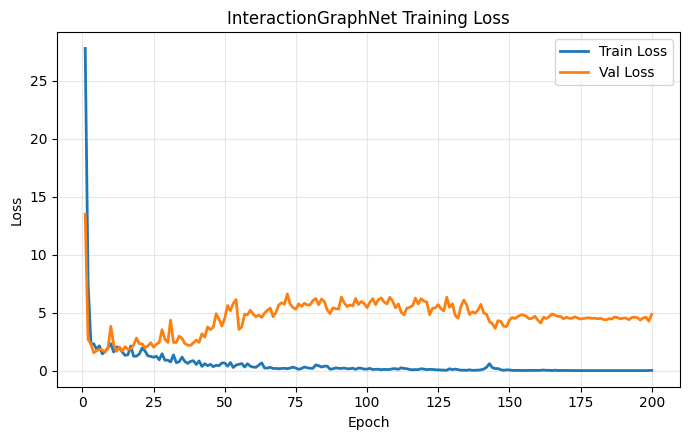

In [10]:
plot_loss_curves(train_loss_history, val_loss_history, title="InteractionGraphNet Training Loss")

## 总结

- 技术路线：交互边聚合的亲和力回归。
- 教学骨架：`nn.Linear() + nn.ReLU()`。
- 主指标：`Pearson R` 和 `RMSE`。